<a href="https://colab.research.google.com/github/emmatorres-bsm/telefonica/blob/main/Versi%C3%B3n_1_TELEFONICA_RETO_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

El objetivo del proyecto es desarrollar un sistema de seguridad capaz de detectar si un audio entrante en una llamada corresponde a una voz humana o a una voz generada artificialmente con fines fraudulentos.

En un entorno corporativo como Telefónica, el coste de permitir el acceso a un atacante fraudulento es especialmente alto.

Por ello, el sistema se diseña priorizando la detección de fraude (`spoof = 1`) frente a la confirmación de legitimidad (`bonafide = 0`).


### **1. PREPARACIÓN DE DATOS**

Primero de todo, se preparan los metadatos y las particiones del dataset que serán utilizadas durante todo el proyecto.

En particular, se utilizará el corpus ASVspoof Logical Access, que contiene grabaciones de voz reales y audios sintéticos generados mediante distintos algoritmos de spoofing, con las siguientes particiones:

- **Train:** entrenamiento y validación cruzada.
- **Dev:** test final ciego.
- **Eval:** reservado inicialmente para posibles experimentos futuros.

### **Variables objetivo**

### y1

Clasificación binaria:

- `0 → bonafide`
- `1 → spoof`

### y2

Tipo de ataque utilizado.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/telefonica/LA.zip" -d "/content/dataset"

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: /content/dataset/LA/ASVspoof2019_LA_eval/flac/LA_E_7787040.flac  
  inflating: /content/dataset/LA/ASVspoof2019_LA_eval/flac/LA_E_2924301.flac  
  inflating: /content/dataset/LA/ASVspoof2019_LA_eval/flac/LA_E_9249366.flac  
  inflating: /content/dataset/LA/ASVspoof2019_LA_eval/flac/LA_E_3442936.flac  
  inflating: /content/dataset/LA/ASVspoof2019_LA_eval/flac/LA_E_7772915.flac  
  inflating: /content/dataset/LA/ASVspoof2019_LA_eval/flac/LA_E_5569336.flac  
  inflating: /content/dataset/LA/ASVspoof2019_LA_eval/flac/LA_E_7773607.flac  
  inflating: /content/dataset/LA/ASVspoof2019_LA_eval/flac/LA_E_7813281.flac  
  inflating: /content/dataset/LA/ASVspoof2019_LA_eval/flac/LA_E_9705954.flac  
  inflating: /content/dataset/LA/ASVspoof2019_LA_eval/flac/LA_E_2427464.flac  
  inflating: /content/dataset/LA/ASVspoof2019_LA_eval/flac/LA_E_1000273.flac  
  inflating: /content/dataset/LA/ASVspoof2019_LA_eval/flac/LA_E_526355

In [3]:
import pandas as pd
import os

***Definición de rutas de las carpetas de la carpeta LA***

In [4]:
path_protocols = '/content/dataset/LA/ASVspoof2019_LA_cm_protocols/'

***Protocolo train***

In [5]:
file_train = os.path.join(path_protocols, 'ASVspoof2019.LA.cm.train.trn.txt')
file_test = os.path.join(path_protocols, 'ASVspoof2019.LA.cm.dev.trl.txt')

In [6]:
def load_metadata(file_path):

    df = pd.read_csv(file_path, sep=' ', header=None,
                     names=['speaker_id', 'file_name', 'ignorar', 'system_id', 'key'])

    df = df.drop(columns=['ignorar'])

    df['y1'] = df['key'].apply(lambda x: 1 if x == 'spoof' else 0)

    df['y2'] = df['system_id']

    return df[['file_name', 'y1', 'y2']]

***Creamos dos dataframes para cada partición de datos***

In [7]:
df_train = load_metadata(file_train)
df_test = load_metadata(file_test)

In [8]:
print(f"tabla de entrenamiento lista con {len(df_train)} audios.")
print(f"tabla de prueba lista con {len(df_test)} audios.")

tabla de entrenamiento lista con 25380 audios.
tabla de prueba lista con 24844 audios.


### **2. EXTRACCIÓN DE CARACTERÍSTICAS**

Transformamos los archivos de audio en variables numéricas que puedan ser procesadas por algoritmos de ML.

Cada audio será procesado con una frecuencia de muestreo de 16 kHz. A continuación, se extraerán 20 coeficientes MFCC, utilizados en reconocimiento de voz y biometría vocal.


In [9]:
import librosa
import numpy as np
from tqdm import tqdm

def extract_features(dataframe, folder_path):
    features_list = []


    for file_name in tqdm(dataframe['file_name']):

        file_path = os.path.join(folder_path, 'flac', file_name + '.flac')

        try:

            y, sr = librosa.load(file_path, sr=16000)


            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)


            mfcc_mean = np.mean(mfcc.T, axis=0)

            features_list.append(mfcc_mean)

        except Exception as e:

            print(f"error en {file_name}: {e}")
            features_list.append(np.zeros(20))


    df_features = pd.DataFrame(features_list, columns=[f'mfcc_{i}' for i in range(20)])


    df_final = pd.concat([dataframe.reset_index(drop=True), df_features], axis=1)

    return df_final

path_audio_train = '/content/dataset/LA/ASVspoof2019_LA_train/'
path_audio_test = '/content/dataset/LA/ASVspoof2019_LA_dev/'

print("Extrayendo características de entrenamiento")
df_train_final = extract_features(df_train, path_audio_train)

print("Extrayendo características de prueba")
df_test_final = extract_features(df_test, path_audio_test)

Extrayendo características de entrenamiento


100%|██████████| 25380/25380 [04:15<00:00, 99.44it/s] 


Extrayendo características de prueba


100%|██████████| 24844/24844 [03:56<00:00, 104.97it/s]


In [10]:
import os
import pandas as pd
import numpy as np
import librosa
from tqdm import tqdm

ruta_train = '/content/drive/MyDrive/telefonica/train_features_mfcc.csv'
ruta_test = '/content/drive/MyDrive/telefonica/test_features_mfcc.csv'

if os.path.exists(ruta_train) and os.path.exists(ruta_test):
    print("¡Archivos CSV encontrados en Drive! Cargando características directamente")


    df_train_final = pd.read_csv(ruta_train)
    df_test_final = pd.read_csv(ruta_test)

    print(f"Tablas cargadas correctamente.")
    print(f"Train: {df_train_final.shape[0]} audios, Test: {df_test_final.shape[0]} audios.")

else:
    print("Archivos CSV no encontrados. Iniciando extracción desde cero")


    def extract_features(dataframe, folder_path):
        features_list = []
        for file_name in tqdm(dataframe['file_name']):
            file_path = os.path.join(folder_path, 'flac', file_name + '.flac')
            try:
                y, sr = librosa.load(file_path, sr=16000)
                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
                mfcc_mean = np.mean(mfcc.T, axis=0)
                features_list.append(mfcc_mean)
            except Exception as e:
                print(f"error en {file_name}: {e}")
                features_list.append(np.zeros(20))

        df_features = pd.DataFrame(features_list, columns=[f'mfcc_{i}' for i in range(20)])
        df_final = pd.concat([dataframe.reset_index(drop=True), df_features], axis=1)
        return df_final

    path_audio_train = '/content/dataset/LA/ASVspoof2019_LA_train/'
    path_audio_test = '/content/dataset/LA/ASVspoof2019_LA_dev/'


    df_train_final = extract_features(df_train, path_audio_train)
    df_test_final = extract_features(df_test, path_audio_test)


    os.makedirs('/content/drive/MyDrive/telefonica/', exist_ok=True)
    df_train_final.to_csv(ruta_train, index=False)
    df_test_final.to_csv(ruta_test, index=False)
    print("Features extraídas y guardadas con éxito en Drive para la próxima vez.")

¡Archivos CSV encontrados en Drive! Cargando características directamente
Tablas cargadas correctamente.
Train: 25380 audios, Test: 24844 audios.


### **3. ANÁLISIS EXPLORATORIO DE DATOS**

El objetivo del análisis exploratorio de datos es comprender la capacidad discriminativa de las características extraídas antes de comenzar el entrenamiento.

Se realizarán tres análisis complementarios:

***3.1. Estudio de solapamiento***

Análisis de la separación entre voces reales y sintéticas.

In [11]:
df = df_train_final.copy()

df = df.drop(columns=['file_name', 'y2'], errors='ignore')

features = df.drop(columns=['y1']).columns

In [12]:
df.head()

,y1,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,...,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19
0,0,-310.40796,43.036842,-18.052126,8.644586,-30.472720,-6.541727,-12.117187,-9.478478,-5.399701,...,-10.453364,-4.147437,-6.144251,-13.564545,-10.693901,-5.905566,-6.242381,1.044785,-2.273914,-5.131492
1,0,-330.95712,50.894707,-19.692842,10.769039,-16.535870,-5.034311,-14.371912,-6.454690,-6.768363,...,-7.348011,-1.828738,-6.318435,-14.385564,-12.833565,-5.424848,-9.297034,-6.153479,-5.778385,-5.371579
2,0,-352.31696,18.402120,0.244028,8.822980,-8.674293,-6.496036,-6.244439,-3.917905,-7.031027,...,-2.998174,-0.438722,-8.049463,-7.104668,-5.658224,-4.877845,-8.579283,-2.346593,-5.417048,-7.137229
3,0,-280.84598,48.768970,-7.991325,21.069437,-34.162148,-4.567614,-8.792074,-16.917734,-13.749961,...,-11.731431,-7.322227,-10.476174,-13.515911,-10.316736,-7.759546,-11.218293,-5.454732,-6.979445,-9.121796
4,0,-301.70840,63.264990,-9.561450,-3.289454,-17.743680,-2.535605,-13.747502,-12.589027,-6.880199,...,-10.377601,-1.839709,-9.889489,-11.866519,-9.166168,-8.872170,-8.615369,-3.015185,-5.162355,-5.872140


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25380 entries, 0 to 25379
Data columns (total 21 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   y1       25380 non-null  int64  
 1   mfcc_0   25380 non-null  float64
 2   mfcc_1   25380 non-null  float64
 3   mfcc_2   25380 non-null  float64
 4   mfcc_3   25380 non-null  float64
 5   mfcc_4   25380 non-null  float64
 6   mfcc_5   25380 non-null  float64
 7   mfcc_6   25380 non-null  float64
 8   mfcc_7   25380 non-null  float64
 9   mfcc_8   25380 non-null  float64
 10  mfcc_9   25380 non-null  float64
 11  mfcc_10  25380 non-null  float64
 12  mfcc_11  25380 non-null  float64
 13  mfcc_12  25380 non-null  float64
 14  mfcc_13  25380 non-null  float64
 15  mfcc_14  25380 non-null  float64
 16  mfcc_15  25380 non-null  float64
 17  mfcc_16  25380 non-null  float64
 18  mfcc_17  25380 non-null  float64
 19  mfcc_18  25380 non-null  float64
 20  mfcc_19  25380 non-null  float64
dtypes: float64(2

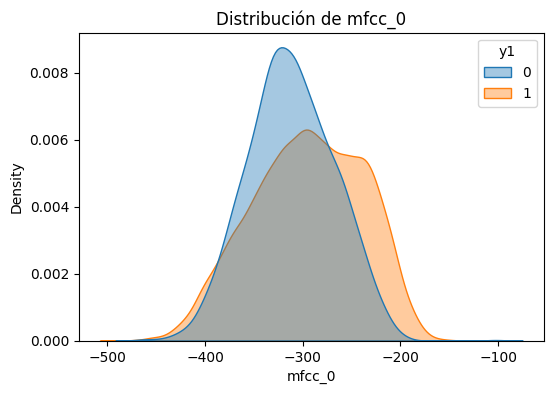

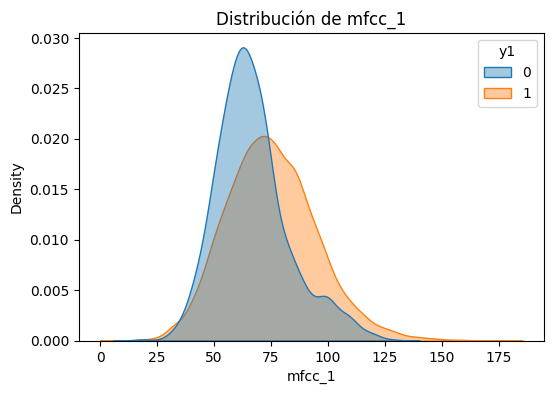

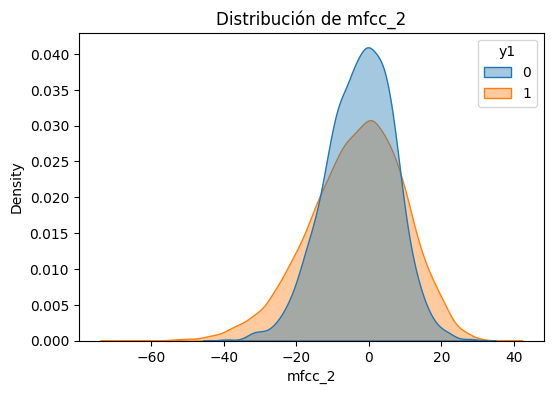

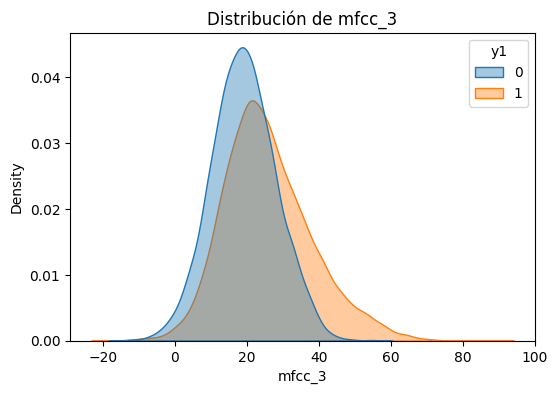

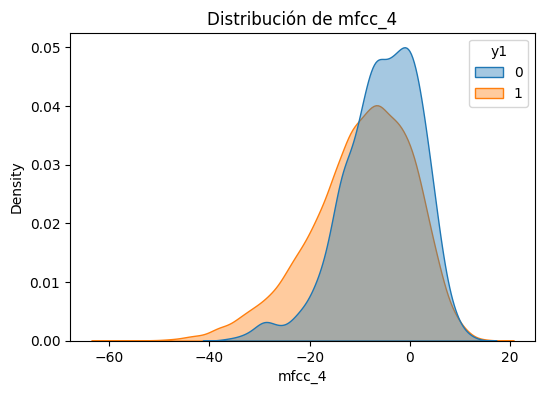

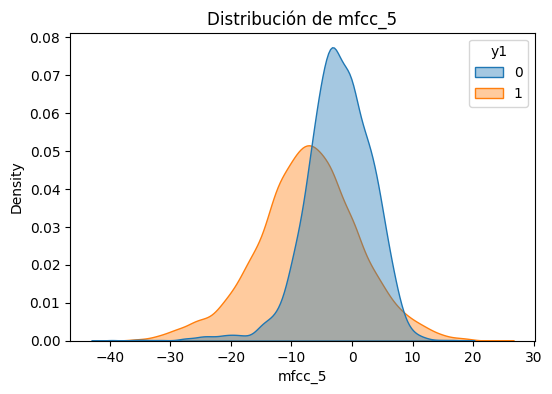

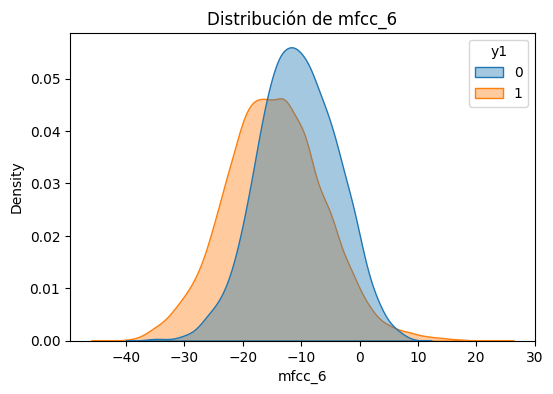

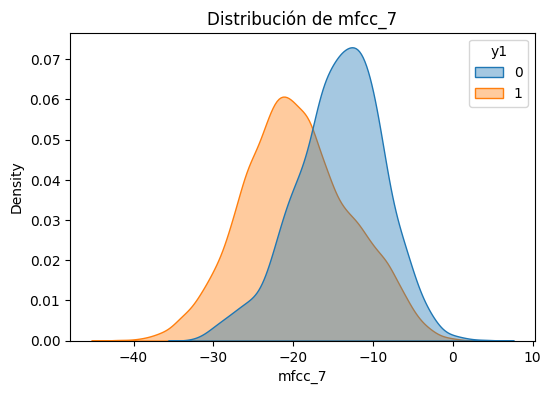

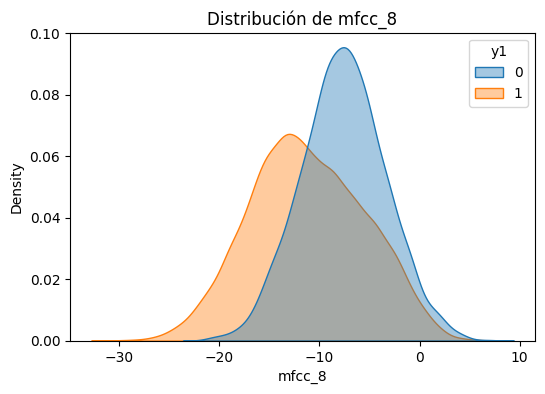

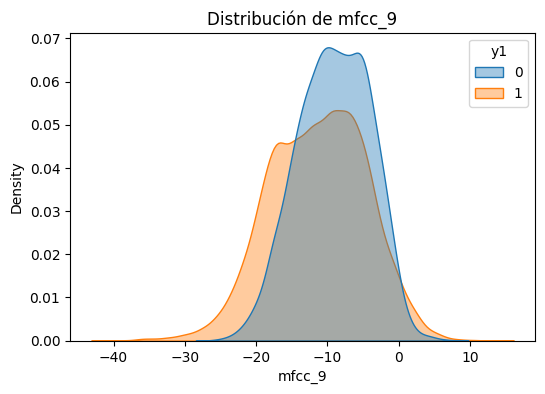

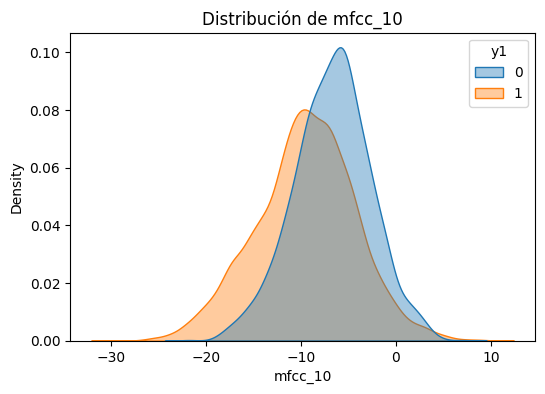

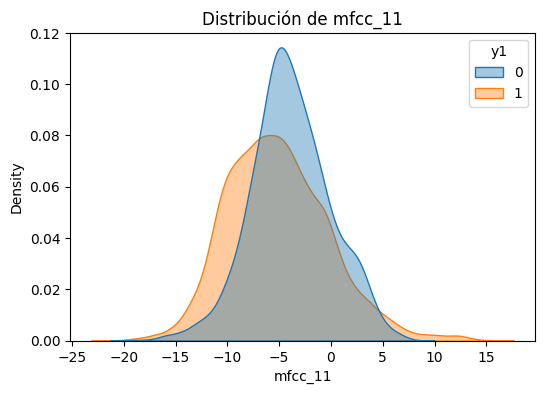

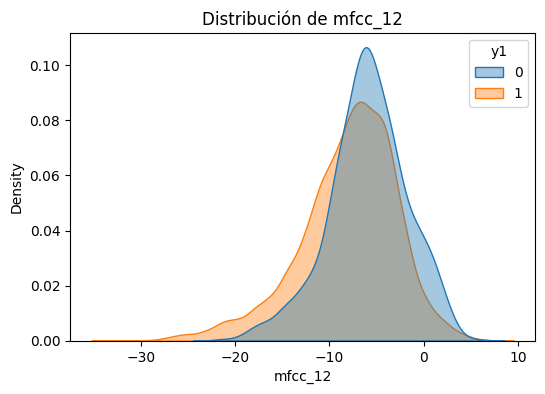

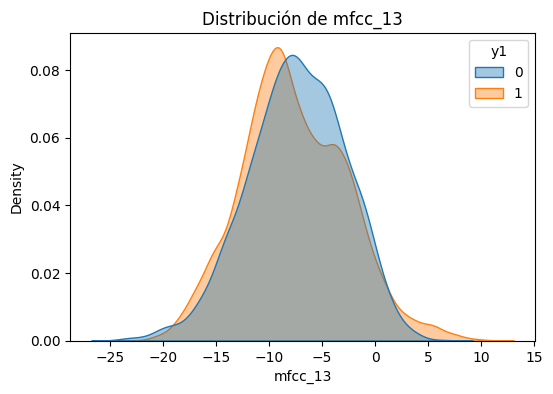

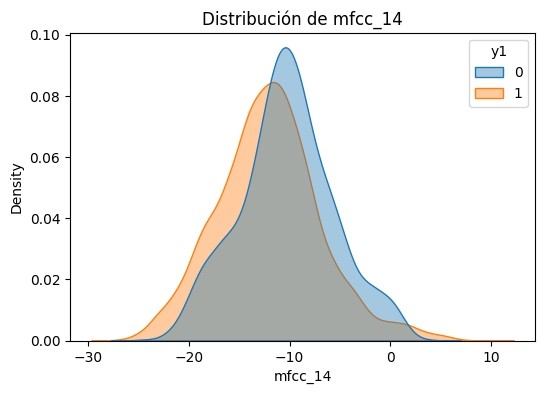

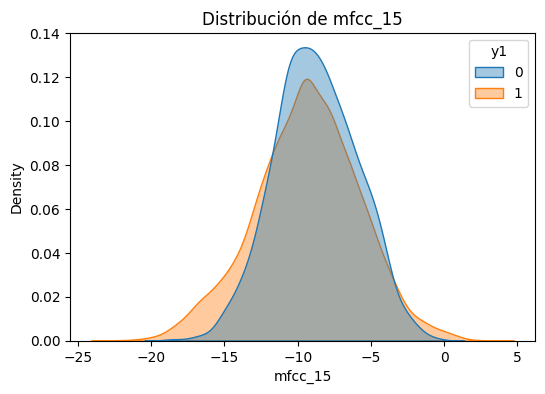

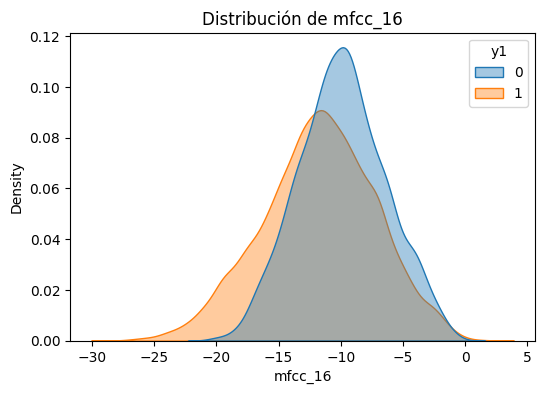

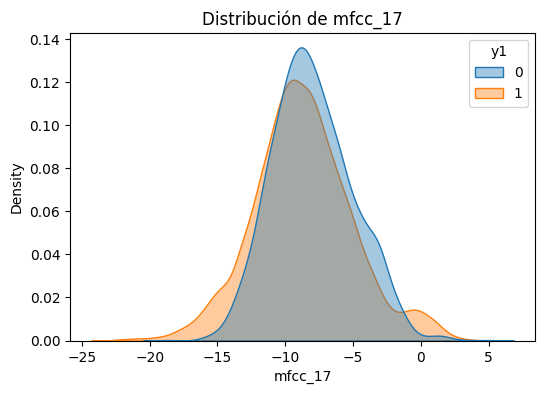

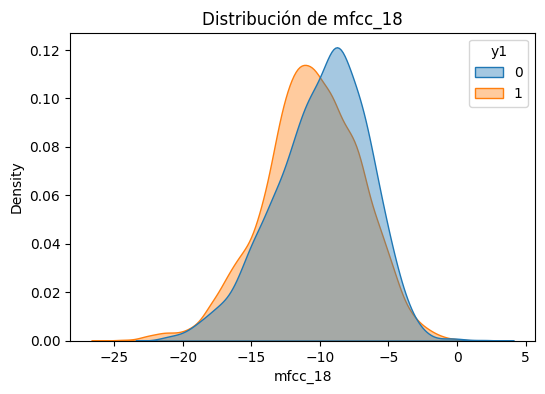

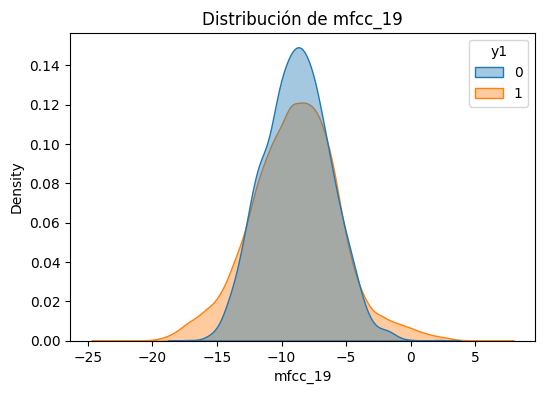

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in features[:20]:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue='y1', fill=True, common_norm=False, alpha=0.4)
    plt.title(f'Distribución de {col}')
    plt.show()

El análisis de solapamiento realizado a los 20 coeficientes MFCC muestra que la capacidad discriminativa no es uniforme entre las distintas variables.

Los coeficientes entre mfcc_3 y mfcc_8 presentan una mayor separación entre voces reales y sintéticas, mientras que los coeficientes superiores (mfcc_13 a mfcc_19) muestran un alto grado de solapamiento, aportando menor información discriminativa.

Este comportamiento es coherente con la naturaleza de los MFCC, donde las primeras componentes capturan la mayor parte de la información relevante.

Adicionalmente, se observa un patrón en múltiples variables, lo que sugiere redundancia y la aplicación posterior de técnicas de selección de características.

***3.2. Matriz de correlación***

Como hemos observado varias variables aportan una información muy similar vamos a usar la matriz de correlación para determinar que MFCC son y eliminarlas si fuese necesario.

In [15]:
corr_matrix = df.drop(columns=['y1']).corr()

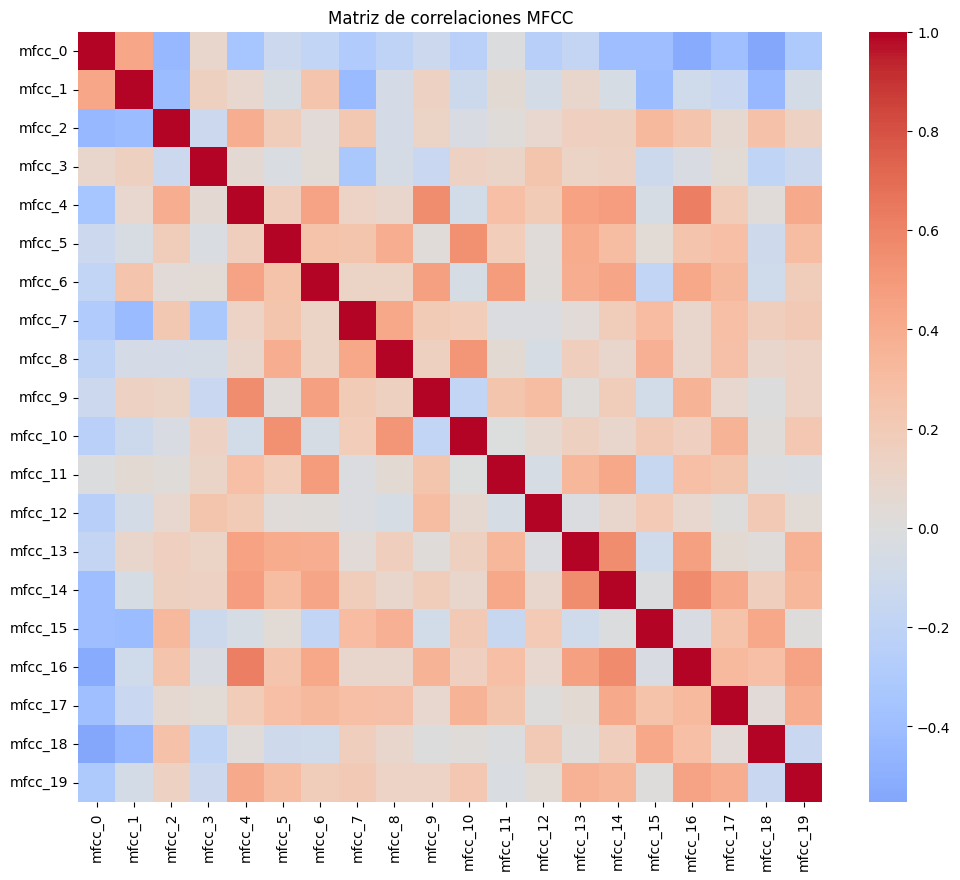

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Matriz de correlaciones MFCC')
plt.show()

La matriz de correlaciones no muestra relaciones extremadamente altas entre variables, lo que indica la ausencia de redundancia total.

Sin embargo, se observan correlaciones moderadas entre varios coeficientes MFCC, especialmente en las componentes intermedias (mfcc_5 a mfcc_8), lo que sugiere que estas variables capturan patrones acústicos similares.
Este resultado confirma el análisis previo de solapamiento, donde estas variables mostraban comportamientos similares en la separación de clases.

No obstante, dado que la redundancia no es extrema, la selección final de variables la basaremos en su importancia predictiva en el modelo.

***3.3. Importancia de variables***

Estimamos qué coeficientes aportan mayor poder predictivo.

In [17]:
X = df.drop(columns=['y1'])
y = df['y1']

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

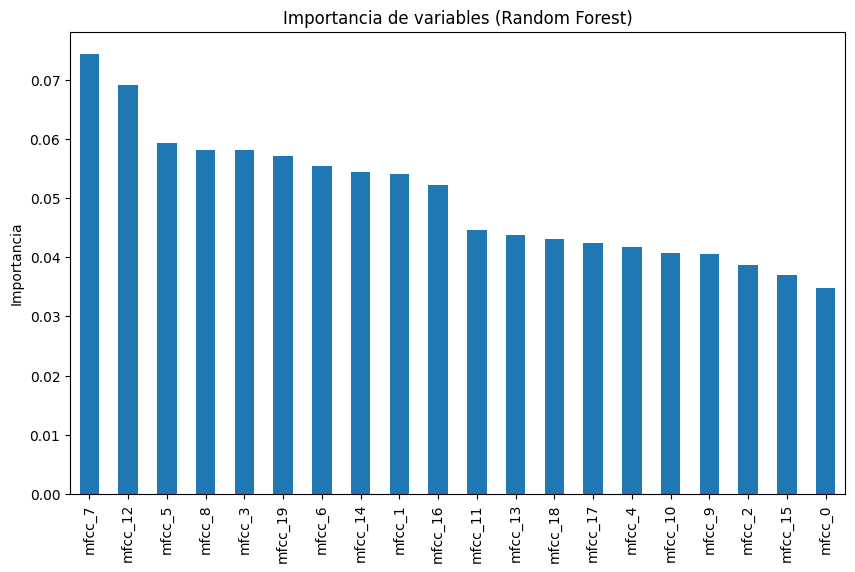

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feat_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_importance.plot(kind='bar')
plt.title('Importancia de variables (Random Forest)')
plt.ylabel('Importancia')
plt.show()

El análisis de importancia de variables muestra que todas las características MFCC contribuyen en cierta medida a la capacidad predictiva del modelo, sin existir variables claramente irrelevantes.

Los coeficientes de orden intermedio (como mfcc_7, mfcc_5 o mfcc_8) presentan mayor peso, lo que confirma el análisis visual previo.

Sin embargo, coeficientes de orden superior también aportan información relevante, aunque en menor medida, lo que sugiere que la detección de deepfakes se basa en la combinación de múltiples patrones acústicos.

En consecuencia, se opta por una selección conservadora de variables, manteniendo aquellas con mayor importancia sin eliminar características que podrían aportar valor conjunto.

### **4. DEFINICIÓN DE MÉTRICAS DE NEGOCIO**

El sistema será evaluado utilizando tres métricas principales. (Nota: En la fase de entrenamiento, estas métricas representan la media obtenida de los 5 pliegues de la validación cruzada para garantizar la robustez del modelo).

**1. Recall de Fraude** : mide la capacidad del sistema para detectar y bloquear intentos reales de estafa. Esta representa la métrica de seguridad más importante del proyecto.

**2. F1-Score:** mide el equilibrio armónico entre recall y precision, penalizando fuertemente a los modelos que detectan mucho fraude a costa de generar demasiadas falsas alarmas y bloquear usuarios reales.

**3. Accuracy global:** mide el porcentaje total de predicciones correctas del modelo. Aunque es la métrica más intuitiva, en este contexto nos servirá para ilustrar un problema común en ciberseguridad: cómo un modelo puede generar un "espejismo" de éxito (ej. 99% de aciertos) simplemente prediciendo siempre la clase mayoritaria en un dataset desbalanceado.

### **5. ENTRENAMIENTO Y COMPARACIÓN DE MODELOS**

En lugar de hacer un simple corte de los datos (una parte para entrenar y otra para testear), utilizaremos la validación cruzada.

En nuestro caso, vamos a dividir nuestro conjunto de datos de entrenamiento en 5 bloques. El proceso funciona así:

El modelo se entrena utilizando 4 de esos bloques.

Se examina intentando predecir los datos del bloque que ha sobrado, el cual nunca ha visto.

Este proceso se repite 5 veces, rotando el bloque de examen hasta que todos los datos han sido usados para evaluar.

Al final, obtenemos la nota media de las 5 rondas. Hacerlo de esta manera nos aporta dos ventajas:

- Nos asegura que la puntuación del modelo es real y no por haber hecho un corte de datos donde los audios falsos eran especialmente fáciles de detectar.

- Nos permite probar diferentes hiperparámetros de un mismo modelo (como el número de árboles) y elegir la mejor sin tener que tocar los datos del Test, evitando así el data leakage.

In [20]:
X_train_val = df_train_final.drop(columns=['file_name', 'y1', 'y2'], errors='ignore')
y_train_val = df_train_final['y1']

X_test = df_test_final.drop(columns=['file_name', 'y1', 'y2'], errors='ignore')
y_test = df_test_final['y1']

print(f"Datos para entrenar y validar: {X_train_val.shape[0]} audios con {X_train_val.shape[1]} variables.")
print(f"Datos para el test final: {X_test.shape[0]} audios.")

Datos para entrenar y validar: 25380 audios con 20 variables.
Datos para el test final: 24844 audios.


***5.1. Regresión Logística***

El objetivo de este primer paso es fijar un umbral mínimo de rendimiento: si un algoritmo más complejo no logra superar a este modelo lineal, no estaría justificado su uso debido al mayor coste computacional.

Para este modelo, evaluamos dos configuraciones ajustando el hiperparámetro de regularización (C):

Versión estándar (C=1.0): El valor por defecto que permite al modelo ajustarse a los datos de forma natural.

Versión regularizada (C=0.01): Aplica una penalización fuerte a los coeficientes para evitar que el modelo dependa demasiado de variables específicas, ayudando a prevenir el sobreajuste (overfitting).

En ambas configuraciones es fundamental el uso del parámetro class_weight='balanced'. Dado que trabajamos con un dataset donde los casos de fraude (spoof) superan masivamente a los humanos (bonafide), este parámetro obliga al algoritmo a dar más peso a los errores cometidos en la clase minoritaria, equilibrando el aprendizaje.

In [21]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import pandas as pd
import numpy as np

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_v1 = LogisticRegression(class_weight='balanced', C=1.0, max_iter=1000, random_state=42)
lr_v2 = LogisticRegression(class_weight='balanced', C=0.01, max_iter=1000, random_state=42)

modelos_lr = {
    "regresión logística (c=1.0)": lr_v1,
    "regresión logística (c=0.01)": lr_v2
}

resultados_lr = {}

print("Validación cruzada para regresión logística")

for nombre, modelo in modelos_lr.items():
    scores = cross_validate(modelo, X_train_val, y_train_val, cv=skf,
                            scoring=['recall', 'f1', 'accuracy'], n_jobs=-1)

    resultados_lr[nombre] = {
        "recall fraude": np.mean(scores['test_recall']),
        "f1-score": np.mean(scores['test_f1']),
        "accuracy": np.mean(scores['test_accuracy'])
    }


df_res_lr = pd.DataFrame(resultados_lr).T
print("Resultados regresión logística")
print(df_res_lr.round(4))

Validación cruzada para regresión logística
Resultados regresión logística
                              recall fraude  f1-score  accuracy
regresión logística (c=1.0)          0.8288    0.8982    0.8312
regresión logística (c=0.01)         0.8286    0.8980    0.8310


La Regresión Logística obtiene resultados muy similares para los dos valores de C probados, lo que significa que el algoritmo ha llegado a su límite.

Desde el punto de vista del negocio, el recall de 0.8287 indica que el modelo detecta aproximadamente el 82.87% de los audios fraudulentos. Sin embargo, todavía deja pasar alrededor del 17.13% de los fraudes, por lo que será necesario comparar este resultado con modelos más complejos como Random Forest, SVM y XGBoost.

***5.2. Random Forest***

Vistos los límites del modelo anterior, damos el salto al Random Forest, un algoritmo más robusto y capaz de detectar patrones de voz complejos. Evaluaremos su rendimiento probando dos configuraciones distintas: 50 y 100 árboles.

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
import pandas as pd
import numpy as np

rf_v1 = RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1)
rf_v2 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

modelos_rf = {
    "random forest (50 árboles)": rf_v1,
    "random forest (100 árboles)": rf_v2
}

resultados_rf = {}

print("Validación cruzada para Random Forest\n")

for nombre, modelo in modelos_rf.items():
    scores = cross_validate(modelo, X_train_val, y_train_val, cv=skf,
                            scoring=['recall', 'f1', 'accuracy'], n_jobs=-1)

    resultados_rf[nombre] = {
        "recall fraude": np.mean(scores['test_recall']),
        "f1-score": np.mean(scores['test_f1']),
        "accuracy": np.mean(scores['test_accuracy'])
    }


df_res_rf = pd.DataFrame(resultados_rf).T
print("Resultados Random Forest")
print(df_res_rf.round(4))

Validación cruzada para Random Forest

Resultados Random Forest
                             recall fraude  f1-score  accuracy
random forest (50 árboles)          0.9962    0.9756    0.9552
random forest (100 árboles)         0.9969    0.9761    0.9561


Un Accuracy global por encima del 95% y un Recall de Fraude cercano al 99.7% son métricas muy altas a primera vista. Estos valores, sumados al hecho de obtener resultados idénticos utilizando 50 o 100 árboles, nos hacen dudar de si el modelo realmente está aprendiendo a distinguir las voces o si simplemente se está aprovechando del desbalanceo de los datos para inflar su nota.

***5.3. Support Vector Machines***

Este algoritmo dibuja un "pasillo" de seguridad entre las clases. Vamos a probar el hiperparámetro kernel, que cambia la forma en la que el algoritmo ve el espacio de datos:

Versión 1 (kernel='linear'): intentará separarlos con una barrera recta. Su rendimiento debería ser muy parecido al de la regresión logística.

Versión 2 (kernel='rbf'): usa una función matemática que proyecta los datos a un espacio tridimensional o superior, permitiendo dibujar fronteras curvas y complejas.

En este caso seguiremos aplicando el ajuste class_weight='balanced' para que el modelo intente compensar el desequilibrio de los datos durante el entrenamiento.

In [24]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold
import pandas as pd
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


svm_v1 = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', class_weight='balanced', max_iter=2000, random_state=42))
])

svm_v2 = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', class_weight='balanced', max_iter=2000, random_state=42))
])

modelos_svm = {
    "svm (lineal escalado)": svm_v1,
    "svm (rbf escalado)": svm_v2
}

resultados_svm = {}

print("Validación cruzada para SVM")

for nombre, modelo in modelos_svm.items():
    scores = cross_validate(modelo, X_train_val, y_train_val, cv=skf,
                            scoring=['recall', 'f1', 'accuracy'], n_jobs=-1)

    resultados_svm[nombre] = {
        "recall fraude": np.mean(scores['test_recall']),
        "f1-score": np.mean(scores['test_f1']),
        "accuracy": np.mean(scores['test_accuracy'])
    }

df_res_svm = pd.DataFrame(resultados_svm).T
print("Resultados SVM")
print(df_res_svm.round(4))

Validación cruzada para SVM
Resultados SVM
                       recall fraude  f1-score  accuracy
svm (lineal escalado)         0.7453    0.8200    0.7080
svm (rbf escalado)            0.9123    0.9538    0.9206


El SVM lineal confirma que usar fronteras rectas no es suficiente para clasificar patrones de voz tan complejos. Por el contrario, el kernel RBF logra adaptarse mucho mejor a los datos y eleva significativamente el rendimiento, dejándolo como nuestro candidato principal para someterlo a la prueba de fuego de la Matriz de Confusión.

***5.4. XGBOOST***

Finalmente, introducimos XGBoost, un potente algoritmo que construye árboles de forma secuencial para ir corrigiendo sus propios errores paso a paso. Para buscar un buen equilibrio, evaluaremos dos configuraciones distintas: una inicial de 50 árboles y otra más compleja de 100 árboles con una profundidad máxima de 4.

In [25]:
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

ratio_clases = len(y_train_val[y_train_val == 0]) / len(y_train_val[y_train_val == 1])


xgb_v1 = XGBClassifier(n_estimators=50, scale_pos_weight=ratio_clases, random_state=42, n_jobs=-1)

xgb_v2 = XGBClassifier(n_estimators=100, max_depth=4, scale_pos_weight=ratio_clases, random_state=42, n_jobs=-1)

modelos_xgb = {
    "xgboost (50 árboles)": xgb_v1,
    "xgboost (100 árboles, profundidad 4)": xgb_v2
}

resultados_xgb = {}

print("Validación cruzada para xgboost")

for nombre, modelo in modelos_xgb.items():

    scores = cross_validate(modelo, X_train_val, y_train_val, cv=skf,
                            scoring=['recall', 'f1', 'accuracy'], n_jobs=-1)

    resultados_xgb[nombre] = {
        "recall fraude": np.mean(scores['test_recall']),
        "f1-score": np.mean(scores['test_f1']),
        "accuracy": np.mean(scores['test_accuracy'])
    }

df_res_xgb = pd.DataFrame(resultados_xgb).T
print("Resultados XGBoost")
print(df_res_xgb.round(4))

Validación cruzada para xgboost
Resultados XGBoost
                                      recall fraude  f1-score  accuracy
xgboost (50 árboles)                         0.9699    0.9794    0.9634
xgboost (100 árboles, profundidad 4)         0.9632    0.9764    0.9582


XGBoost ofrece un Accuracy global y un Recall que superan el 95% en su versión de 50 árboles. Sin embargo, dado que el Random Forest anterior mostraba puntuaciones aún más altas y sospechosas, descartamos elegir este modelo de forma precipitada y dejamos que la Matriz de Confusión dicte el veredicto final.

### **6. SELECCIÓN Y EVALUACIÓN DEL MODELO FINAL**

***6.1 Comparación de modelos con validación cruzada***

In [26]:
df_lr = df_res_lr.copy()
df_rf = df_res_rf.copy()
df_svm = df_res_svm.copy()
df_xgb = df_res_xgb.copy()

df_comparacion_cv = pd.concat([
    df_lr,
    df_rf,
    df_svm,
    df_xgb
])

df_comparacion_cv = df_comparacion_cv.reset_index()
df_comparacion_cv = df_comparacion_cv.rename(columns={"index": "modelo"})

df_comparacion_cv = df_comparacion_cv.sort_values(
    by=["recall fraude", "f1-score", "accuracy"],
    ascending=False
)

print("Comparación final de modelos con validación cruzada:")
display(df_comparacion_cv.round(4))

Comparación final de modelos con validación cruzada:


,modelo,recall fraude,f1-score,accuracy
3,random forest (100 árboles),0.9969,0.9761,0.9561
2,random forest (50 árboles),0.9962,0.9756,0.9552
6,xgboost (50 árboles),0.9699,0.9794,0.9634
7,"xgboost (100 árboles, profundidad 4)",0.9632,0.9764,0.9582
5,svm (rbf escalado),0.9123,0.9538,0.9206
0,regresión logística (c=1.0),0.8288,0.8982,0.8312
1,regresión logística (c=0.01),0.8286,0.8980,0.8310
4,svm (lineal escalado),0.7453,0.8200,0.7080


Una vez entrenadas distintas familias de modelos, se comparan sus resultados mediante validación cruzada estratificada de 5 pliegues.

La métrica principal utilizada para ordenar los modelos es el recall de la clase spoof, ya que el objetivo prioritario de esta primera iteración es minimizar los falsos negativos y maximizar la detección de fraude.

Como métricas complementarias, se utilizan el F1-score, para penalizar modelos excesivamente agresivos que generen falsas alertas, y el Accuracy Global, para medir el porcentaje total de aciertos brutos e identificar posibles sesgos por el desbalanceo.

Este enfoque permite construir una primera versión orientada principalmente a seguridad.

***6.2 Elección del mejor modelo según validación cruzada***

El modelo con mejor rendimiento en validación cruzada fue Random Forest con 100 árboles, alcanzando un recall de fraude de 0.9969, un F1-score de 0.9761 y un accuracy global de 0.9561. Dado que el objetivo principal es minimizar los falsos negativos de la clase spoof, este modelo se selecciona como el mejor candidato para la evaluación final sobre el conjunto de test

***6.3 Entrenamiento del modelo final con train***

In [27]:
from sklearn.ensemble import RandomForestClassifier


modelo_final = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


modelo_final.fit(X_train_val, y_train_val)

print("Modelo final entrenado correctamente.")
print("Modelo seleccionado: Random Forest con 100 árboles")

Modelo final entrenado correctamente.
Modelo seleccionado: Random Forest con 100 árboles


Una vez seleccionado Random Forest con 100 árboles como mejor candidato mediante validación cruzada, se entrena de nuevo el modelo utilizando todo el conjunto de entrenamiento.

La validación cruzada permite comparar modelos de forma robusta, pero el modelo final debe entrenarse con todos los datos disponibles antes de evaluarlo sobre el conjunto de test. De esta manera, el modelo aprovecha toda la información del entrenamiento para realizar las predicciones finales.

***6.3 Evaluación del modelo final con test***

Para realizar la evaluación definitiva, ponemos a prueba el modelo entrenado enfrentándolo al conjunto de test completo extraído originalmente de la carpeta dev. En esta celda calcularemos las métricas globales para comprobar si mantiene el rendimiento observado en el entrenamiento, dejando la inspección detallada de la matriz de confusión para el siguiente paso.

In [28]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = modelo_final.predict(X_test)

accuracy_test = accuracy_score(y_test, y_pred)
recall_test = recall_score(y_test, y_pred, pos_label=1)
f1_test = f1_score(y_test, y_pred, pos_label=1)

print("Resultados finales en el conjunto de test:")
print(f"Accuracy Global: {accuracy_test:.4f}")
print(f"Recall Fraude (Spoof): {recall_test:.4f}")
print(f"F1-score: {f1_test:.4f}")



Resultados finales en el conjunto de test:
Accuracy Global: 0.9107
Recall Fraude (Spoof): 0.9978
F1-score: 0.9525


Resultados finales en el conjunto de test:
Accuracy Global: 0.9107
Recall Fraude (Spoof): 0.9978
F1-score: 0.9525
--------------------------------------------------
Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

      humano       0.89      0.15      0.25      2548
      fraude       0.91      1.00      0.95     22296

    accuracy                           0.91     24844
   macro avg       0.90      0.57      0.60     24844
weighted avg       0.91      0.91      0.88     24844

--------------------------------------------------


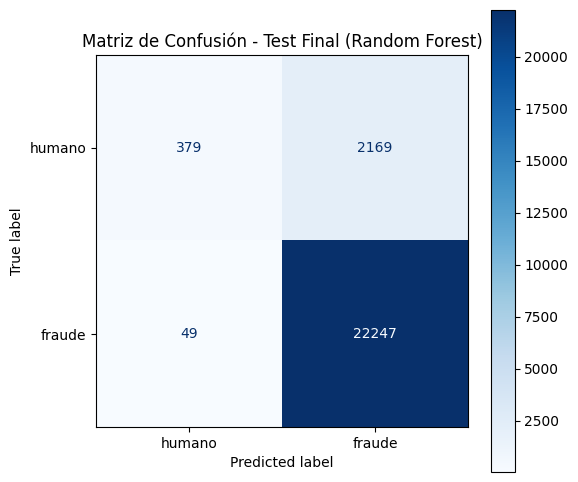

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


y_pred = modelo_final.predict(X_test)


accuracy_test = accuracy_score(y_test, y_pred)
recall_test = recall_score(y_test, y_pred, pos_label=1)
f1_test = f1_score(y_test, y_pred, pos_label=1)

print("Resultados finales en el conjunto de test:")
print(f"Accuracy Global: {accuracy_test:.4f}")
print(f"Recall Fraude (Spoof): {recall_test:.4f}")
print(f"F1-score: {f1_test:.4f}")
print("-" * 50)

print("Reporte de Clasificación Detallado:")
print(classification_report(y_test, y_pred, target_names=['humano', 'fraude']))
print("-" * 50)


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['humano', 'fraude'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
ax.set_title("Matriz de Confusión - Test Final (Random Forest)")


plt.savefig('matriz_confusion_rf.png', bbox_inches='tight')

### **7. CONCLUSIÓN**

Al desglosar el reporte de clasificación descubrimos el verdadero comportamiento del modelo, donde la clase de fraude muestra un rendimiento aparentemente perfecto con un recall del 99.78% y una precisión del 91%. Sin embargo, la clase humana se desploma con un recall de apenas el 15%, lo que significa que el algoritmo es incapaz de reconocer al 85% de los usuarios legítimos y los etiqueta erróneamente como atacantes, arrastrando su F1-score a un deficiente 0.25.

Este fenómeno explica por qué la precisión global se mantenía tan alta en un 91%; al haber una presencia masiva de muestras de fraude en el conjunto de test (más de 22,000 frente a apenas 2,500 humanos), el modelo simplemente se limitó a clasificar casi todo como spoof para asegurar una nota inflada. Por esta razón, descartamos directamente esta versión del modelo, ya que un sistema que bloquea masivamente a los clientes reales es comercialmente inviable y nos obliga a buscar soluciones de balanceo en la siguiente fase.